# HGE SRD Sandbox 
## "How many stars do you need to measure the metallicity gradient in the far disk?"

From Gail:

- Simulated populations are here: https://www.dropbox.com/scl/fo/pvdxje8lmlbfqo677wko8/APbNInClVRnjiwKDze8r7YU?rlkey=b93n93es9lbl7oec60tucyytt&dl=0. I'd just read 'em in and stack the tables (the *.csv files). They're centered in very small boxes at the (l,b) coordinates in the file name, but the tables contain 'l' and 'b' coordinates if you need to recover that, so don't worry about parsing the file names.
print(dat.colnames): 
```
['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist', 'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR', 'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius', 'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J', '2MASS_H', '2MASS_Ks', 'IRAC_3.6', 'IRAC_4.5']
```
- There is some "actual" metallicity gradient in here, set by the galaxy model I used, and encoded in the "Fe/H_evolved" column in the table. What is that number?
- Let's assume 15% distance uncertainties and 0.05 dex metallicity uncertainties. If you had 1e5 stars sampling the radius range evenly, and refit the gradient, what is the bias/uncertainty on the inferred value? What if we had 1e3 stars? 10 stars?
- Now, what if 50% of those stars were within 5 kpc of the galactic center, 25% between 5-8 kpc, and only 25% beyond 8 kpc? How does the uncertainty change with both sample size and this skewed distribution?
- Based on the above, do you have a sense of sample size needed to recover the gradient to a precision of ~0.01 dex/kpc? How important are the stars with R>8 kpc?

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from astropy.table import Table
from astropy.io import fits
from astropy import units, coordinates
import pandas as pd
import os
from matplotlib.colors import LogNorm, LinearSegmentedColormap
import matplotlib.patheffects as patheffects
import matplotlib.patches as patches
from tqdm import tqdm


In [2]:
# Define Plotting Parameters
default_plotting_params = {
    "axes.labelsize": 36,
    "xtick.labelsize": 36,
    "ytick.labelsize": 36,
    "text.usetex": False,
    "lines.linewidth": 1,
    "axes.titlesize": 22,
    "font.family": "serif",
    "font.size": 36,
}
plt.rcParams.update(default_plotting_params)

# Load in the data + stack

In [3]:
# Load in the data
all_csv_files = [
    f.name
    for f in os.scandir("hge_gums_marshall")
    if f.name.endswith(".csv") and f.name.startswith("hge_gums_marshall_")
]

# Concatenate all files
all_stars = [pd.read_csv(f"hge_gums_marshall/{f}") for f in all_csv_files]
all_stars = pd.concat(all_stars)

In [4]:
all_stars

,pop,iMass,age,Fe/H_initial,Mass,In_Final_Phase,Dist,l,b,vr_bc,...,log_radius,phase,Gaia_G_EDR3,Gaia_BP_EDR3,Gaia_RP_EDR3,2MASS_J,2MASS_H,2MASS_Ks,IRAC_3.6,IRAC_4.5
0,0.0,1.051876,10.0,0.075153,1.050080,0.0,5.454683,351.996260,1.015126,-111.826370,...,0.989002,2.0,30.080151,36.434705,25.521712,17.408140,14.718586,13.582695,12.727116,12.650010
1,0.0,1.041818,10.0,0.040514,1.040526,0.0,6.021261,351.999190,0.994428,-16.188280,...,0.890104,2.0,38.623755,47.951379,32.092050,20.282089,16.553991,14.892068,13.619235,13.447102
2,0.0,1.111406,10.0,0.553189,1.110752,0.0,6.703132,351.990550,1.010101,87.696487,...,0.485219,2.0,33.839205,40.560263,29.042828,20.515515,17.764045,16.562431,15.661265,15.568415
3,0.0,1.118253,10.0,0.461041,1.116244,0.0,6.908469,352.001700,0.997139,271.583070,...,1.173581,2.0,40.375362,50.712715,33.162955,20.098833,15.963265,14.091279,12.682706,12.542306
4,0.0,1.121273,10.0,0.509376,1.119831,0.0,6.947862,351.998090,1.011312,-35.708584,...,0.997516,2.0,32.109492,39.030497,27.170066,18.369431,15.477930,14.223167,13.292109,13.231201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5798,10.0,0.935102,10.0,-0.422844,0.934293,0.0,15.212288,4.004875,3.013540,-97.749838,...,0.448934,2.0,23.015013,24.957791,21.416028,18.810884,17.782078,17.452331,17.210773,17.198700
5799,10.0,1.031463,10.0,-0.007402,1.029761,0.0,16.055368,4.007393,2.989372,-69.844821,...,0.931259,2.0,21.401146,23.508794,19.668646,16.842468,15.675408,15.302157,15.041334,15.075913
5800,10.0,0.975297,10.0,-0.228637,0.974372,0.0,16.974638,3.988531,2.999922,-84.804548,...,0.600298,2.0,23.103509,25.247499,21.360161,18.503026,17.377986,17.009394,16.742154,16.741981
5801,10.0,0.893354,10.0,-0.747014,0.892315,0.0,17.839710,3.992264,2.992892,-29.760164,...,0.631843,2.0,22.860457,24.950427,21.163700,18.364207,17.277444,16.922163,16.655831,16.630291


In [5]:
all_stars.columns

Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius',
       'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J',
       '2MASS_H', '2MASS_Ks', 'IRAC_3.6', 'IRAC_4.5'],
      dtype='object')

In [6]:
# Convert (l,b,dist) to Galactic (R,Z,phi)
all_coords = coordinates.SkyCoord(
    frame="galactic",
    l=all_stars["l"],
    b=all_stars["b"],
    distance=all_stars["Dist"],
    unit=(units.deg, units.deg, units.kpc),
)

all_coords = all_coords.transform_to(coordinates.Galactocentric)

gal_x = all_coords.x / units.kpc
gal_y = all_coords.y / units.kpc
gal_z = all_coords.z / units.kpc
gal_r = np.sqrt(((all_coords.x) ** 2.0) + ((all_coords.y) ** 2.0)) / units.kpc

In [7]:
def plot_sun_and_gc(
    ax,
    size: float = 1,
    r_sun: float = -8.122,
    add_bar: bool = False,
    labels: bool = True,
) -> None:
    """Marks the sun and the GC on a plot"""
    # Plot GC
    for i, mc in enumerate(["w", "k"]):
        ax.scatter(
            [0],
            [0],
            marker="+",
            c=mc,
            zorder=12 + i,
            s=(400 - (i * 100)) * size,
            lw=(5 - i * 2) * size,
            snap=False,
        )
    # Plot Sun
    ax.scatter(
        [r_sun],
        [0],
        marker="o",
        c="k",
        facecolor="k",
        s=250 * size,
        zorder=12,
        label="Sun",
        lw=2 * size,
        path_effects=[patheffects.withStroke(linewidth=5, foreground="w")],
    )
    # dot in center for sun symbol
    ax.scatter(
        [r_sun],
        [0],
        marker=".",
        c="w",
        s=50 * size,
        zorder=13,
        snap=False,
    )
    if labels:
        ax.text(
            r_sun,
            1 * size,
            "Sun",
            horizontalalignment="center",
            verticalalignment="bottom",
            zorder=13,
            color="k",
            fontsize=24 * size,
            weight="bold",
            path_effects=[
                patheffects.withStroke(linewidth=5 * size, foreground="w")
            ],
        )
        ax.text(
            0,
            1 * size,
            "Galactic\nCenter",
            horizontalalignment="center",
            verticalalignment="bottom",
            zorder=13,
            color="k",
            fontsize=24 * size,
            weight="bold",
            path_effects=[
                patheffects.withStroke(linewidth=5 * size, foreground="w")
            ],
        )
    if add_bar:  # ellipse for bar location
        bar_angle = 25 if r_sun > 0 else -25
        gbar = patches.Ellipse(
            (0, 0),
            10.0,
            0.4 * 10.0,
            angle=bar_angle,
            facecolor="None",
            edgecolor="k",
        )
        ax.add_patch(gbar)

    return

/var/folders/pt/4pxym4x563d4rqpwzshf5dkh0001rb/T/ipykernel_1433/869513925.py:22: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(


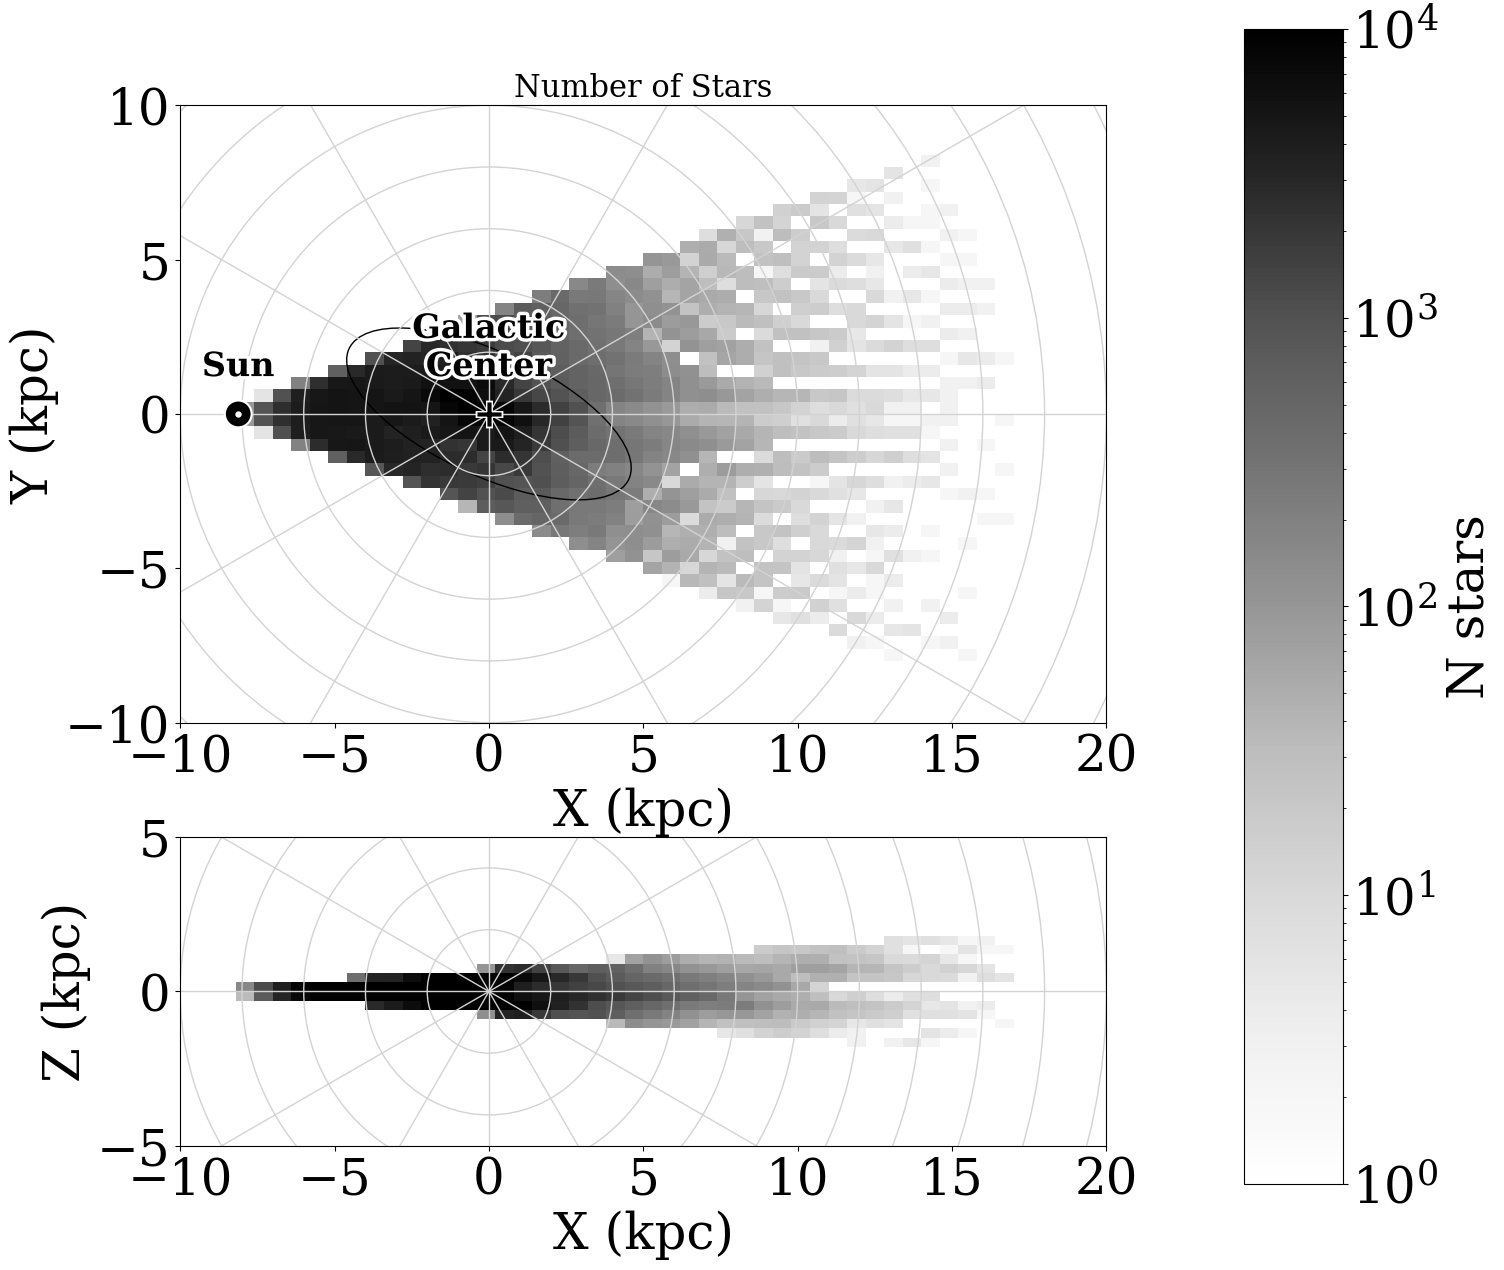

In [ ]:
plt.figure(figsize=(15, 15))
ax0 = plt.subplot2grid((3, 10), (0, 0), colspan=8, rowspan=2)
ax1 = plt.subplot2grid((3, 10), (2, 0), colspan=8, rowspan=1)
ax_c = plt.subplot2grid((3, 10), (0, 9), colspan=1, rowspan=3)

im = ax0.hist2d(
    gal_x,
    gal_y,
    cmap="Greys",
    bins=50,
    range=[[-10, 20], [-10, 10]],
    norm=LogNorm(1, 1e4),
)
ax0.set_ylim(-10, 10)
ax0.set_xlabel("X (kpc)")
ax0.set_ylabel("Y (kpc)")
ax0.set_title("Number of Stars")
plt.colorbar(im[3], cax=ax_c, label="N stars")
plot_sun_and_gc(ax0, add_bar=True)

# ================
im = ax1.hist2d(
    gal_x,
    gal_z,
    cmap="Greys",
    bins=50,
    range=[[-10, 20], [-7.5, 7.5]],
    norm=LogNorm(1, 1e4),
)


ax1.set_ylim(-5, 5)
ax1.set_xlabel("X (kpc)")
ax1.set_ylabel("Z (kpc)")


for ax in [ax0, ax1]:
    ax.set_xlim(-10, 20)
    ax.set_aspect("equal")
    for m in np.arange(0, 180, 30):
        linx = np.linspace(-20, 20, 100)
        ax.plot(linx, np.tan(np.deg2rad(m)) * linx, c="lightgray")
    # add circle grid
    for r in np.arange(0, 30, 2):
        circgrid = plt.Circle(
            (0, 0), r, facecolor="None", edgecolor="lightgray"
        )
        ax.add_patch(circgrid)

plt.subplots_adjust(hspace=0)
# plt.tight_layout()
plt.show()

In [71]:
x_samp = np.linspace(-10, 20, 60)
y_samp = np.linspace(-10, 10, 40)
z_samp = np.linspace(-5, 5, 20)

xy_map = np.zeros((len(x_samp), len(y_samp)))
xz_map = np.zeros((len(x_samp), len(z_samp)))

dx = (x_samp[1] - x_samp[0]) / 2
dy = (y_samp[1] - y_samp[0]) / 2
dz = (z_samp[1] - z_samp[0]) / 2

feh = all_stars["Fe/H_evolved"]

for ix, x in enumerate(x_samp):
    xmask = (gal_x >= x - dx) & (gal_x <= x + dx)
    for iy, y in enumerate(y_samp):
        ymask = (gal_y >= y - dy) & (gal_y <= y + dy)
        xy_mask = xmask & ymask
        xy_map[ix][iy] = np.nanmedian(feh[xy_mask])

    for iz, z in enumerate(z_samp):
        zmask = (gal_z >= z - dz) & (gal_z <= z + dz)
        xz_mask = xmask & zmask
        f = np.nanmedian(feh[xz_mask])
        xz_map[ix][iz] = np.nanmedian(feh[xz_mask])


/Users/jimig/anaconda3/envs/sdss/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


/var/folders/pt/4pxym4x563d4rqpwzshf5dkh0001rb/T/ipykernel_1433/869513925.py:22: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax.scatter(


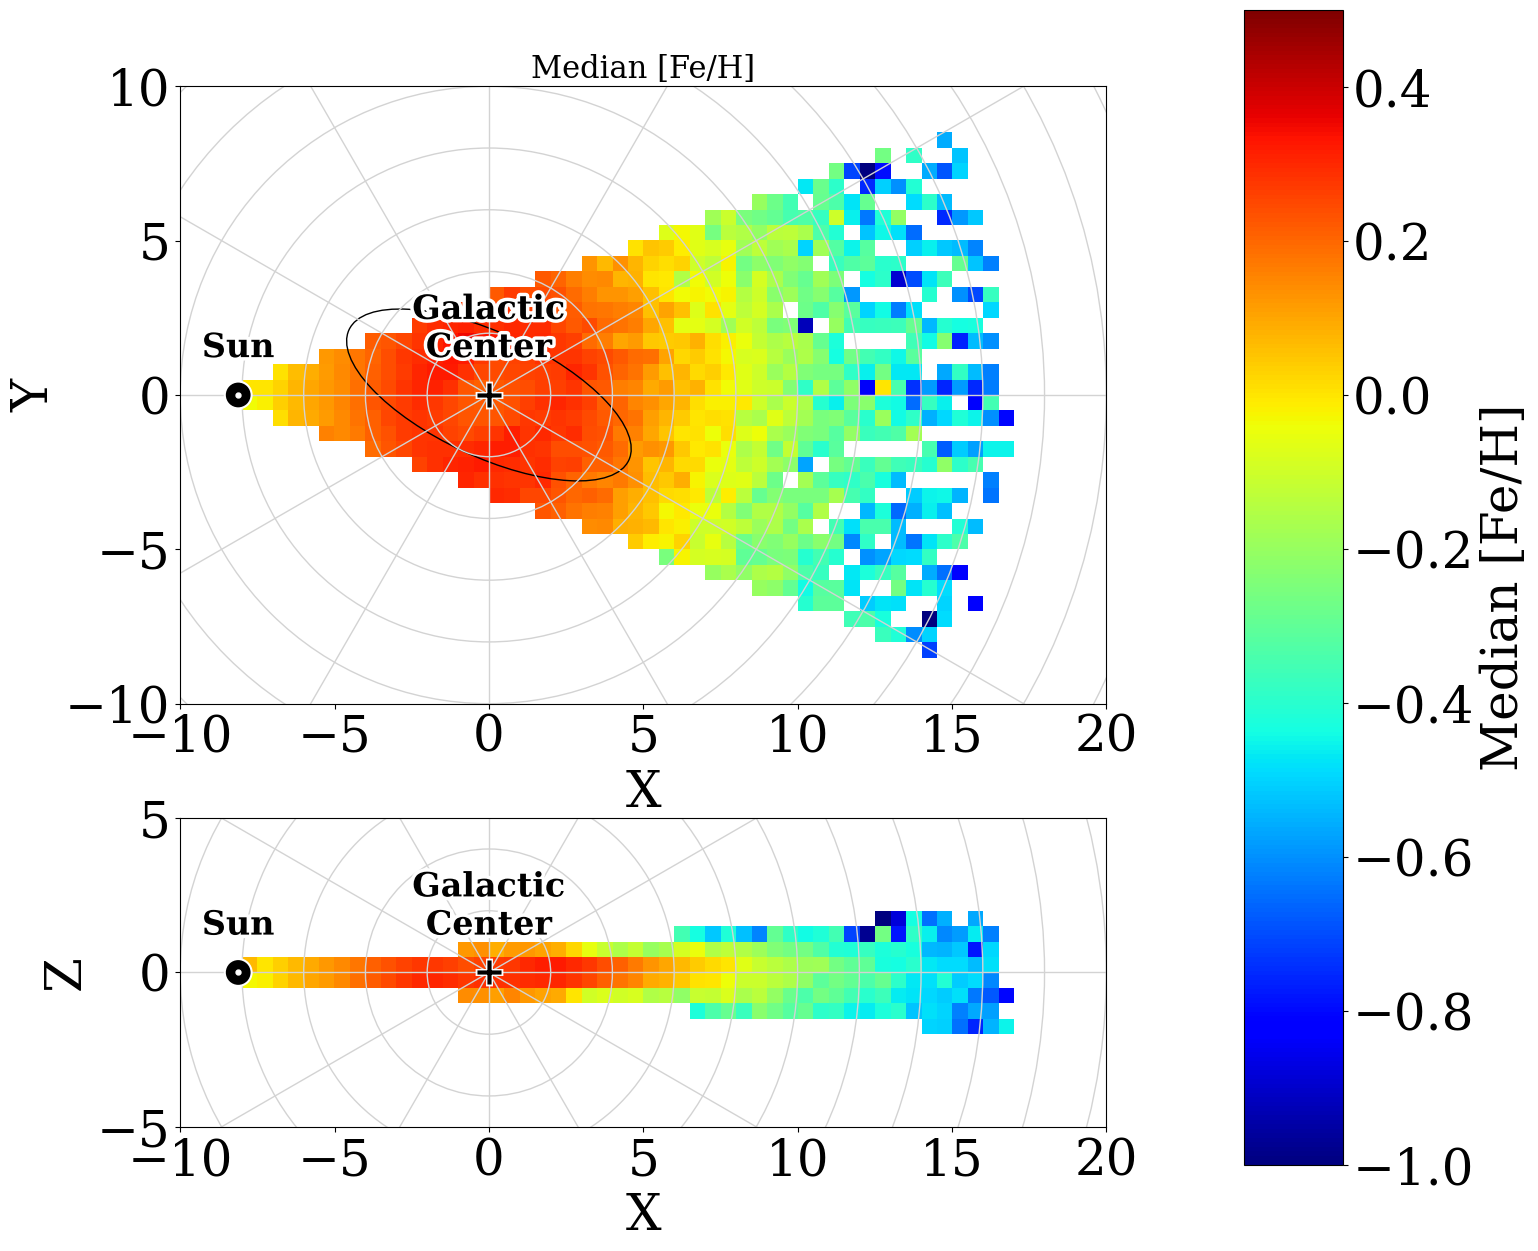

In [102]:
plt.figure(figsize=(15, 15))
ax0 = plt.subplot2grid((3, 10), (0, 0), colspan=8, rowspan=2)
ax1 = plt.subplot2grid((3, 10), (2, 0), colspan=8, rowspan=1)
ax_c = plt.subplot2grid((3, 10), (0, 9), colspan=1, rowspan=3)

im = ax0.imshow(
    xy_map.T, cmap="jet", vmin=-1, vmax=0.5, extent=[-10, 20, -10, 10]
)

ax0.set_ylim(-10, 10)
ax0.set_xlabel("X")
ax0.set_ylabel("Y")
ax0.set_title("Median [Fe/H]")
plt.colorbar(im, cax=ax_c, label="Median [Fe/H]")
plot_sun_and_gc(ax0, add_bar=True)

# ================

im = ax1.imshow(
    xz_map.T, cmap="jet", vmin=-1, vmax=0.5, extent=[-10, 20, -5, 5]
)
plot_sun_and_gc(ax1, add_bar=False)

ax1.set_ylim(-5, 5)
ax1.set_xlabel("X")
ax1.set_ylabel("Z")

for ax in [ax0, ax1]:
    ax.set_xlim(-10, 20)
    ax.set_aspect("equal")
    for m in np.arange(0, 180, 30):
        linx = np.linspace(-20, 20, 100)
        ax.plot(linx, np.tan(np.deg2rad(m)) * linx, c="lightgray")
    # add circle grid
    for r in np.arange(0, 30, 2):
        circgrid = plt.Circle(
            (0, 0), r, facecolor="None", edgecolor="lightgray"
        )
        ax.add_patch(circgrid)

plt.subplots_adjust(hspace=0)
# plt.tight_layout()
plt.show()

# Determine the True Gradient

0.0<z<0.1
Slope from medians: [-0.06045024  0.47430758]
Slope from all: [-0.05758141  0.40756828]
0.1<z<0.2
Slope from medians: [-0.03269689  0.37951177]
Slope from all: [-0.0463652   0.32032761]
0.2<z<0.30000000000000004
Slope from medians: [-0.04686225  0.37324648]
Slope from all: [-0.02602951  0.19741837]
0.30000000000000004<z<0.4
Slope from medians: [-0.0545482   0.36257718]
Slope from all: [-0.03450254  0.17339043]
0.4<z<0.5
Slope from medians: [-0.05501119  0.3237017 ]
Slope from all: [-0.02515037  0.09026503]
0.5<z<0.6
Slope from medians: [-0.0384223   0.19416699]
Slope from all: [-0.02363383  0.03371716]
0.6000000000000001<z<0.7000000000000001
Slope from medians: [-0.03580754  0.14002276]
Slope from all: [-0.03628127  0.03743527]
0.7000000000000001<z<0.8
Slope from medians: [-0.0350268   0.07038121]
Slope from all: [-0.0268394  -0.07604331]
0.8<z<0.9
Slope from medians: [-0.02465919 -0.03277584]
Slope from all: [-0.01105372 -0.22264489]
0.9<z<1.0
Slope from medians: [ 0.0074643

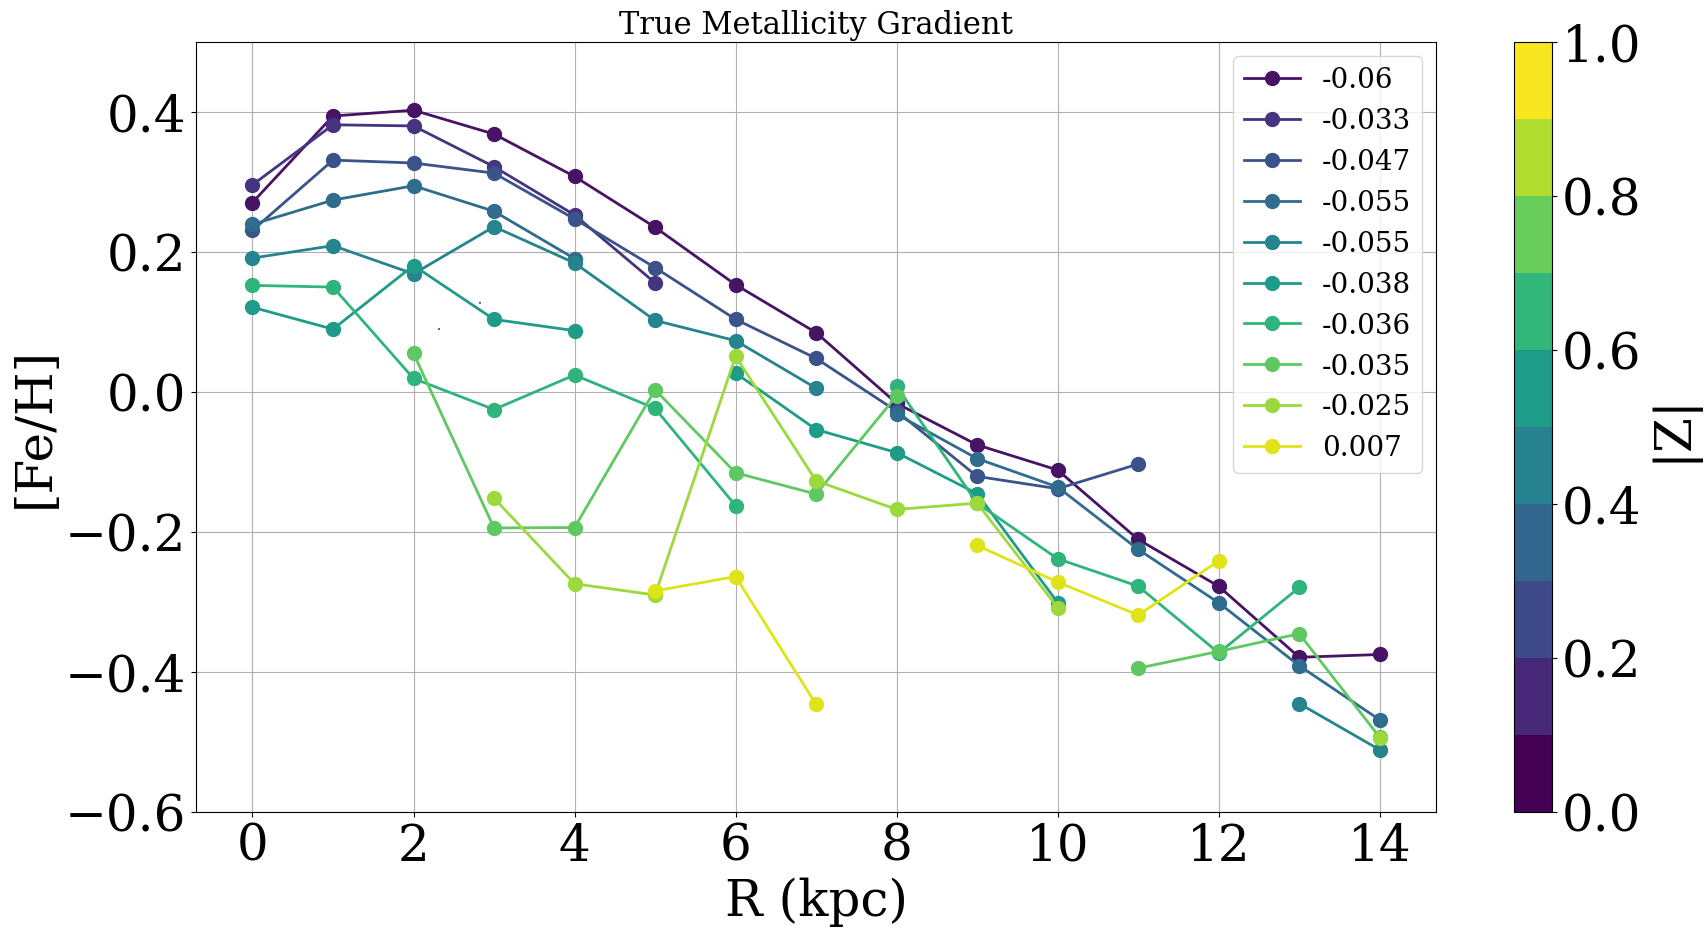

In [79]:
plt.figure(figsize=(20, 10))
segmented_cmap = LinearSegmentedColormap.from_list(
    "", mpl.cm.viridis(np.linspace(0, 0.99, 10)), N=10
)
plt.scatter(
    gal_r[:2],
    all_stars["Fe/H_evolved"][:2],
    marker=".",
    s=1,
    c=np.abs(gal_z[:2]),
    cmap=segmented_cmap,
    vmin=0,
    vmax=1,
)
# plt.ylim(-2.5, 1)
plt.ylim(-0.6, 0.5)
plt.xlabel("R (kpc)")
plt.ylabel("[Fe/H]")
plt.colorbar(label="|Z|")
plt.grid()

feh = np.array(all_stars["Fe/H_evolved"])
# Measure gradient for various z_bins
true_slopes = []
for i, z_bin in enumerate(np.arange(0, 1, 0.1)):
    zmin = z_bin
    zmax = z_bin + 0.1
    data_mask = np.where((np.abs(gal_z) > zmin) & (np.abs(gal_z) <= zmax))[0]

    # Straight line fit
    m, cov = np.polyfit(gal_r[data_mask], feh[data_mask], 1, cov=True)
    true_slopes.append(m[0])
    # plt.plot(
    #     np.linspace(0, 20),
    #     m * np.linspace(0, 20) + b,
    #     c=mpl.cm.viridis(z_bin + 0.05),
    #     lw=5,
    #     label=f"{round(m, 2)}",
    # )
    # Running median?
    running_median = []
    running_scatter = []
    for r_bin in np.arange(0, 15, 1):
        r_mask = np.where(
            (np.abs(gal_z) > zmin)
            & (np.abs(gal_z) <= zmax)
            & (gal_r > r_bin)
            & (gal_r <= r_bin + 0.5)
            & (gal_x >= 0)
        )[0]
        median_feh = np.nanmedian(feh[r_mask])
        running_median.append(median_feh)
        running_scatter.append(np.nanstd(feh[r_mask]))

    running_median = np.array(running_median)
    med_slope = np.polyfit(
        np.array(np.arange(0, 15, 1))[np.isfinite(running_median)],
        np.array(running_median)[np.isfinite(running_median)],
        1,
    )
    med_scatter = np.nanmedian(running_scatter)
    print(f"{zmin}<z<{zmax}")
    print(f"Slope from medians: {med_slope}")
    print(f"Slope from all: {m}")
    print("=" * 50)

    plt.plot(
        np.arange(0, 15, 1),
        running_median,
        marker="o",
        markersize=10,
        c=mpl.cm.viridis(z_bin + 0.05),
        zorder=10,
        lw=2,
        label=f"{round(med_slope[0], 3)}",  # $\pm$ {round(med_scatter, 2)}",
        # label=f"{round(m[0], 3)}",  # \pm {np.sqrt(cov[0][0])}",
    )


plt.legend(fontsize=20)
plt.title("True Metallicity Gradient")
plt.savefig("true metallicity gradient")
plt.show()

true_gradient = -0.06045024

# Generate Sample with uncertainty

- Let's assume 15% distance uncertainties and 0.05 dex metallicity uncertainties. If you had 1e5 stars sampling the radius range evenly, and refit the gradient, what is the bias/uncertainty on the inferred value? What if we had 1e3 stars? 10 stars?
- Now, what if 50% of those stars were within 5 kpc of the galactic center, 25% between 5-8 kpc, and only 25% beyond 8 kpc? How does the uncertainty change with both sample size and this skewed distribution?
- Based on the above, do you have a sense of sample size needed to recover the gradient to a precision of ~0.01 dex/kpc? How important are the stars with R>8 kpc?

In [93]:
def generate_random_sample(n_stars, dist_uncertainty, feh_uncertainty):
    """Generate a random sample with n_stars"""
    r_bins = 10  # 2 kpc sized bings = from the SRD
    r_samp = np.linspace(0, 20, r_bins + 1)

    uncertain_dists = [
        np.random.normal(d, d * dist_uncertainty) for d in all_stars["Dist"]
    ]
    uncertain_fehs = [
        np.random.normal(f, feh_uncertainty) for f in all_stars["Fe/H_evolved"]
    ]
    # uncertain_dists = [d for d in all_stars["Dist"]]
    # uncertain_fehs = [d for d in all_stars["Fe/H_initial"]]

    # Generate coordinates for the uncertain distances
    all_coords = coordinates.SkyCoord(
        frame="galactic",
        l=all_stars["l"],
        b=all_stars["b"],
        distance=uncertain_dists,
        unit=(units.deg, units.deg, units.kpc),
    )
    all_coords = all_coords.transform_to(coordinates.Galactocentric)
    gal_x = all_coords.x / units.kpc
    gal_y = all_coords.y / units.kpc
    gal_z = all_coords.z / units.kpc
    gal_r = np.sqrt(((gal_x) ** 2.0) + ((gal_y) ** 2.0))

    return_sample = []
    for i, r in enumerate(r_samp[:-1]):
        samp = np.where(
            (gal_r >= r)
            & (gal_r <= r_samp[i + 1])
            & (np.abs(gal_z) <= 0.1)
            & (gal_x > 0)
        )[0]
        if len(samp) >= int(n_stars / r_bins):
            random_select = np.random.choice(
                samp, int(n_stars / r_bins), replace=False
            )
            return_sample += [ix for ix in random_select]
        else:
            return_sample += [ix for ix in samp]

    return_dict = {
        "gal_x": np.array(gal_x)[return_sample],
        "gal_y": np.array(gal_y)[return_sample],
        "gal_z": np.array(gal_z)[return_sample],
        "gal_r": np.array(gal_r)[return_sample],
        "feh": np.array(uncertain_fehs)[return_sample],
    }

    return return_dict


def run_gradient_sim(test_samples, dist_uncertainty, feh_uncertainty):
    slope = []
    slope_err = []
    median_slopes = []
    median_errs = []

    for n in tqdm(test_samples):
        samp = generate_random_sample(n, dist_uncertainty, feh_uncertainty)
        m, cov = np.polyfit(samp["gal_r"], samp["feh"], 1, cov=True)
        slope.append(m[0])
        slope_err.append(np.sqrt(cov[0][0]))

        running_median = []
        running_scatter = []
        for r_bin in np.arange(0, 15, 1):
            r_mask = np.where(
                (samp["gal_r"] >= r_bin)
                & (samp["gal_r"] <= r_bin + 0.5)
                & (np.abs(samp["gal_z"]) <= 0.1)  # focus on midplane for now
                & (np.abs(samp["gal_x"]) > 0)  # far side of disk only
            )[0]
            median_feh = np.nanmedian(samp["feh"][r_mask])
            running_median.append(median_feh)
            running_scatter.append(np.nanstd(samp["feh"][r_mask]))

        running_median = np.array(running_median)
        med_slope, cov = np.polyfit(
            np.array(np.arange(0, 15, 1))[np.isfinite(running_median)],
            np.array(running_median)[np.isfinite(running_median)],
            1,
        )
        med_scatter = np.nanmedian(running_scatter)
        median_slopes.append(med_slope)
        median_errs.append(med_scatter)

    return slope, slope_err, median_slopes, median_errs

## Test true gradient can be recovered with a random sample

  0%|          | 0/100 [00:00<?, ?it/s]/Users/jimig/anaconda3/envs/sdss/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/jimig/anaconda3/envs/sdss/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
100%|██████████| 100/100 [01:40<00:00,  1.01s/it]


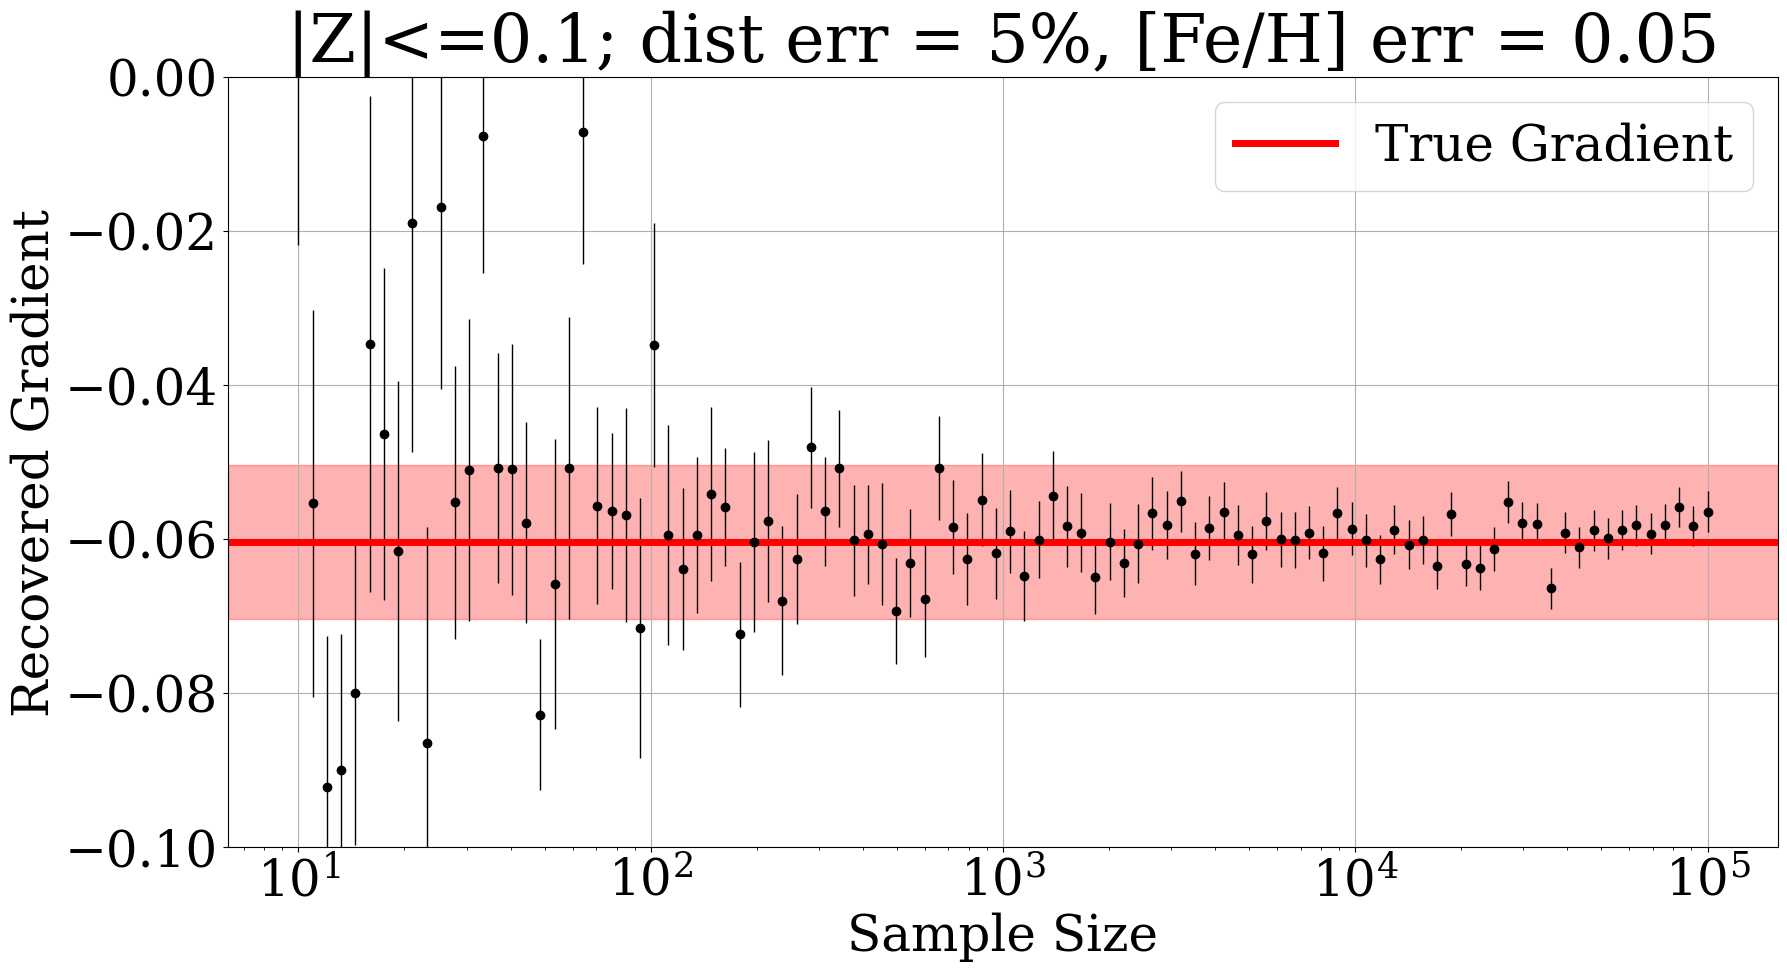

In [94]:
test_samples = np.logspace(1, 5, 100)

slope, slope_err, median_slopes, median_errs = run_gradient_sim(
    test_samples, dist_uncertainty=0.05, feh_uncertainty=0.05
)

plt.figure(figsize=(20, 10))
plt.errorbar(
    test_samples,
    median_slopes,
    yerr=np.array(slope_err) * 2,
    marker="o",
    c="k",
    linestyle="None",
)

plt.axhline(-0.06045024, c="red", lw=5, label="True Gradient")
plt.axhspan(-0.06045024 - 0.01, -0.06045024 + 0.01, color="red", alpha=0.3)

# plt.axhline(-0.05256763, c="red", lw=5, label="True Gradient")

plt.title("|Z|<=0.1; dist err = 5%, [Fe/H] err = 0.05", fontsize=48)
plt.legend()
plt.grid()
plt.ylim(-0.1, 0)
plt.xlabel("Sample Size")
plt.ylabel("Recovered Gradient")
plt.xscale("log")
plt.savefig("slope_5p.png")
plt.show()

## Higher distance uncertainty = 15%

100%|██████████| 100/100 [01:40<00:00,  1.01s/it]


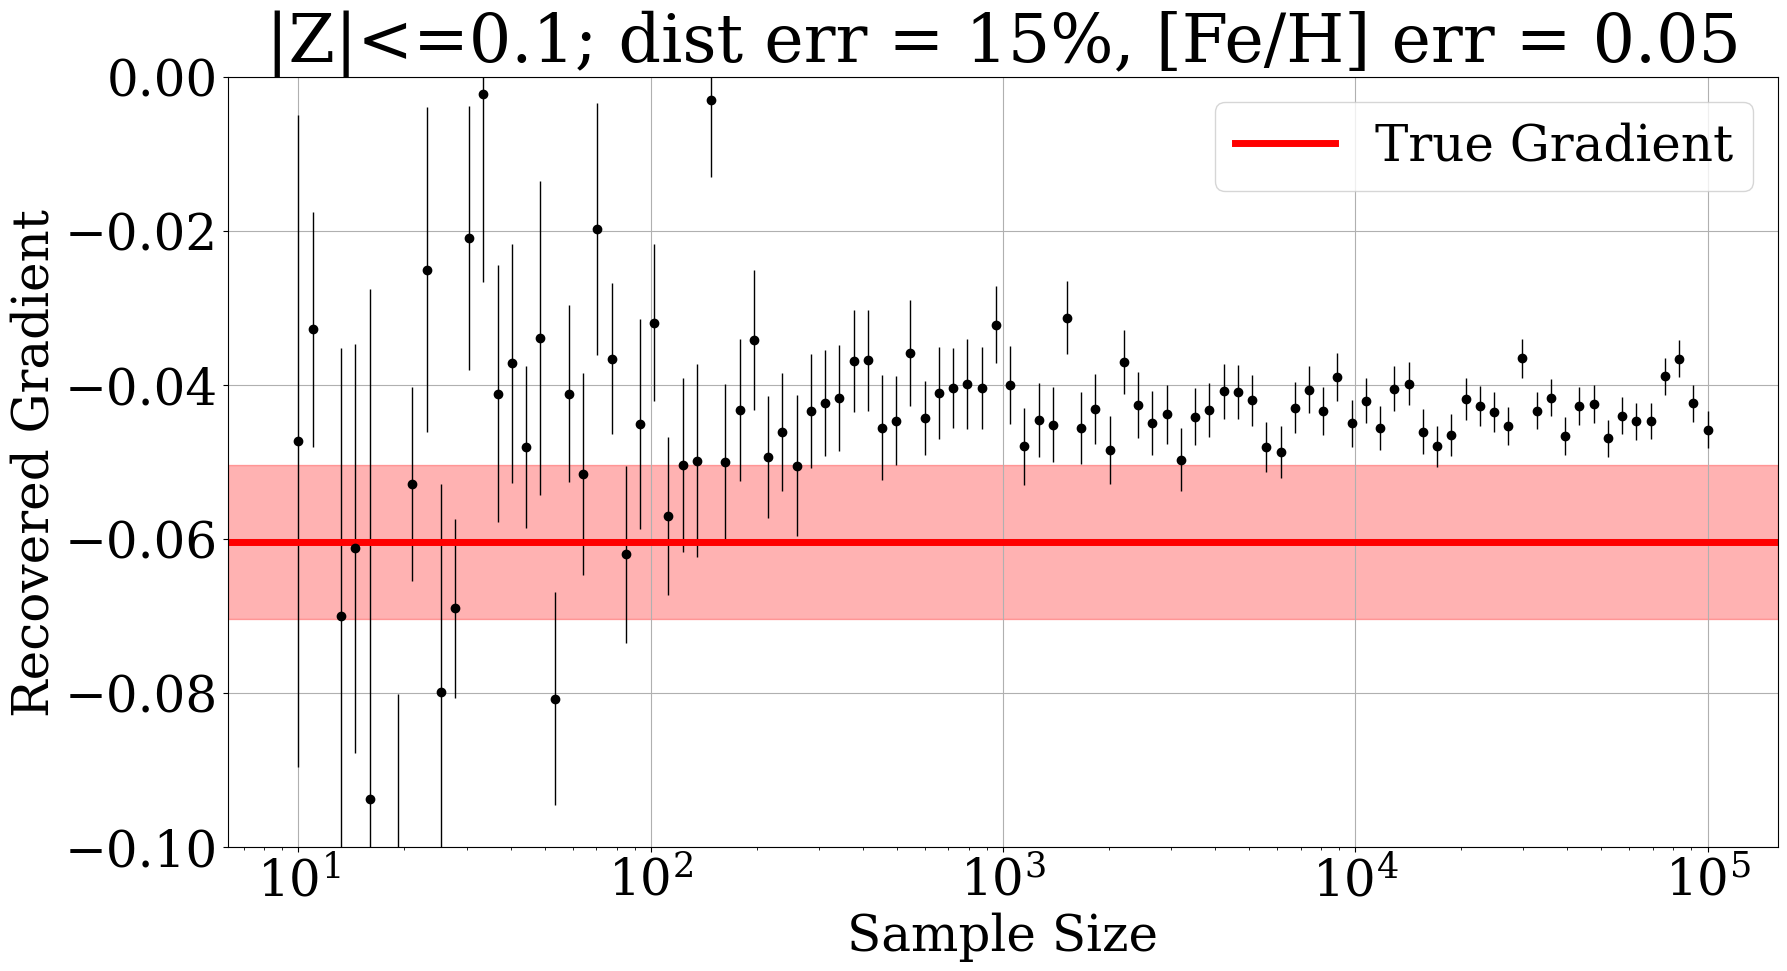

In [95]:
test_samples = np.logspace(1, 5, 100)

slope, slope_err, median_slopes, median_errs = run_gradient_sim(
    test_samples, dist_uncertainty=0.15, feh_uncertainty=0.05
)

plt.figure(figsize=(20, 10))
plt.errorbar(
    test_samples,
    median_slopes,
    yerr=np.array(slope_err) * 2,
    marker="o",
    c="k",
    linestyle="None",
)

plt.axhline(-0.06045024, c="red", lw=5, label="True Gradient")
plt.axhspan(-0.06045024 - 0.01, -0.06045024 + 0.01, color="red", alpha=0.3)

# plt.axhline(-0.05256763, c="red", lw=5, label="True Gradient")

plt.title("|Z|<=0.1; dist err = 15%, [Fe/H] err = 0.05", fontsize=48)
plt.legend()
plt.grid()
plt.ylim(-0.1, 0)
plt.xlabel("Sample Size")
plt.ylabel("Recovered Gradient")
plt.xscale("log")
plt.savefig("slope_15p.png")
plt.show()

# Now for a skewed position sample:

- 50% R < 5 kpc
- 25% 5 < R < 8 kpc
- 25% R > 8 kpc


In [ ]:
def generate_random_sample(n_stars, percents):
    """
    Generate a random sample with n_stars
    percents correspond to R<5, 5<R<8, and R>8 kpc bins
    """
    p1, p2, p3 = percents
    dist_uncertainty = 0.05
    feh_uncertainty = 0.05

    uncertain_dists = [
        np.random.normal(d, d * dist_uncertainty) for d in all_stars["Dist"]
    ]
    uncertain_fehs = [
        np.random.normal(f, feh_uncertainty) for f in all_stars["Fe/H_evolved"]
    ]
    # uncertain_dists = [d for d in all_stars["Dist"]]
    # uncertain_fehs = [d for d in all_stars["Fe/H_evolved"]]

    # Generate coordinates for the uncertain distances
    all_coords = coordinates.SkyCoord(
        frame="galactic",
        l=all_stars["l"],
        b=all_stars["b"],
        distance=uncertain_dists,
        unit=(units.deg, units.deg, units.kpc),
    )
    all_coords = all_coords.transform_to(coordinates.Galactocentric)
    gal_x = all_coords.x / units.kpc
    gal_y = all_coords.y / units.kpc
    gal_z = all_coords.z / units.kpc
    gal_r = np.sqrt(((gal_x) ** 2.0) + ((gal_y) ** 2.0))

    return_sample = []

    # 50% R<5
    samp = np.where(
        (gal_r >= 0) & (gal_r <= 5) & (np.abs(gal_z) <= 0.1) & (gal_x > 0)
    )[0]
    if len(samp) >= int(n_stars * p1):
        random_select = np.random.choice(
            samp, int(n_stars * p1), replace=False
        )
        return_sample += [ix for ix in random_select]
    else:
        return_sample += [ix for ix in samp]

    # 90% 5<R<8
    samp = np.where(
        (gal_r >= 5) & (gal_r <= 8) & (np.abs(gal_z) <= 0.1) & (gal_x > 0)
    )[0]
    if len(samp) >= int(n_stars * p2):
        random_select = np.random.choice(
            samp, int(n_stars * p2), replace=False
        )
        return_sample += [ix for ix in random_select]
    else:
        return_sample += [ix for ix in samp]

    # 10% R>8
    samp = np.where(
        (gal_r >= 8) & (gal_r <= 30) & (np.abs(gal_z) <= 0.1) & (gal_x > 0)
    )[0]
    if len(samp) >= int(n_stars * p3):
        random_select = np.random.choice(
            samp, int(n_stars * p3), replace=False
        )
        return_sample += [ix for ix in random_select]
    else:
        return_sample += [ix for ix in samp]

    return_dict = {
        "gal_x": np.array(gal_x)[return_sample],
        "gal_y": np.array(gal_y)[return_sample],
        "gal_z": np.array(gal_z)[return_sample],
        "gal_r": np.array(gal_r)[return_sample],
        "feh": np.array(uncertain_fehs)[return_sample],
    }

    return return_dict


def run_gradient_sim(test_samples, test_percents):
    slope = []
    slope_err = []
    median_slopes = []
    median_errs = []

    for n in tqdm(test_samples):
        samp = generate_random_sample(n, test_percents)
        m, cov = np.polyfit(samp["gal_r"], samp["feh"], 1, cov=True)
        slope.append(m[0])
        slope_err.append(np.sqrt(cov[0][0]))

        running_median = []
        running_scatter = []
        for r_bin in np.arange(0, 15, 1):
            r_mask = np.where(
                (samp["gal_r"] >= r_bin)
                & (samp["gal_r"] <= r_bin + 0.5)
                & (np.abs(samp["gal_z"]) <= 0.1)  # focus on midplane for now
                & (np.abs(samp["gal_x"]) > 0)  # far side of disk only
            )[0]
            median_feh = np.nanmedian(samp["feh"][r_mask])
            running_median.append(median_feh)
            running_scatter.append(np.nanstd(samp["feh"][r_mask]))

        running_median = np.array(running_median)
        med_slope, cov = np.polyfit(
            np.array(np.arange(0, 15, 1))[np.isfinite(running_median)],
            np.array(running_median)[np.isfinite(running_median)],
            1,
        )
        med_scatter = np.nanmedian(running_scatter)
        median_slopes.append(med_slope)
        median_errs.append(med_scatter)

    return slope, slope_err, median_slopes, median_errs

  0%|          | 0/100 [00:00<?, ?it/s]/Users/jimig/anaconda3/envs/sdss/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/jimig/anaconda3/envs/sdss/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
100%|██████████| 100/100 [01:38<00:00,  1.01it/s]


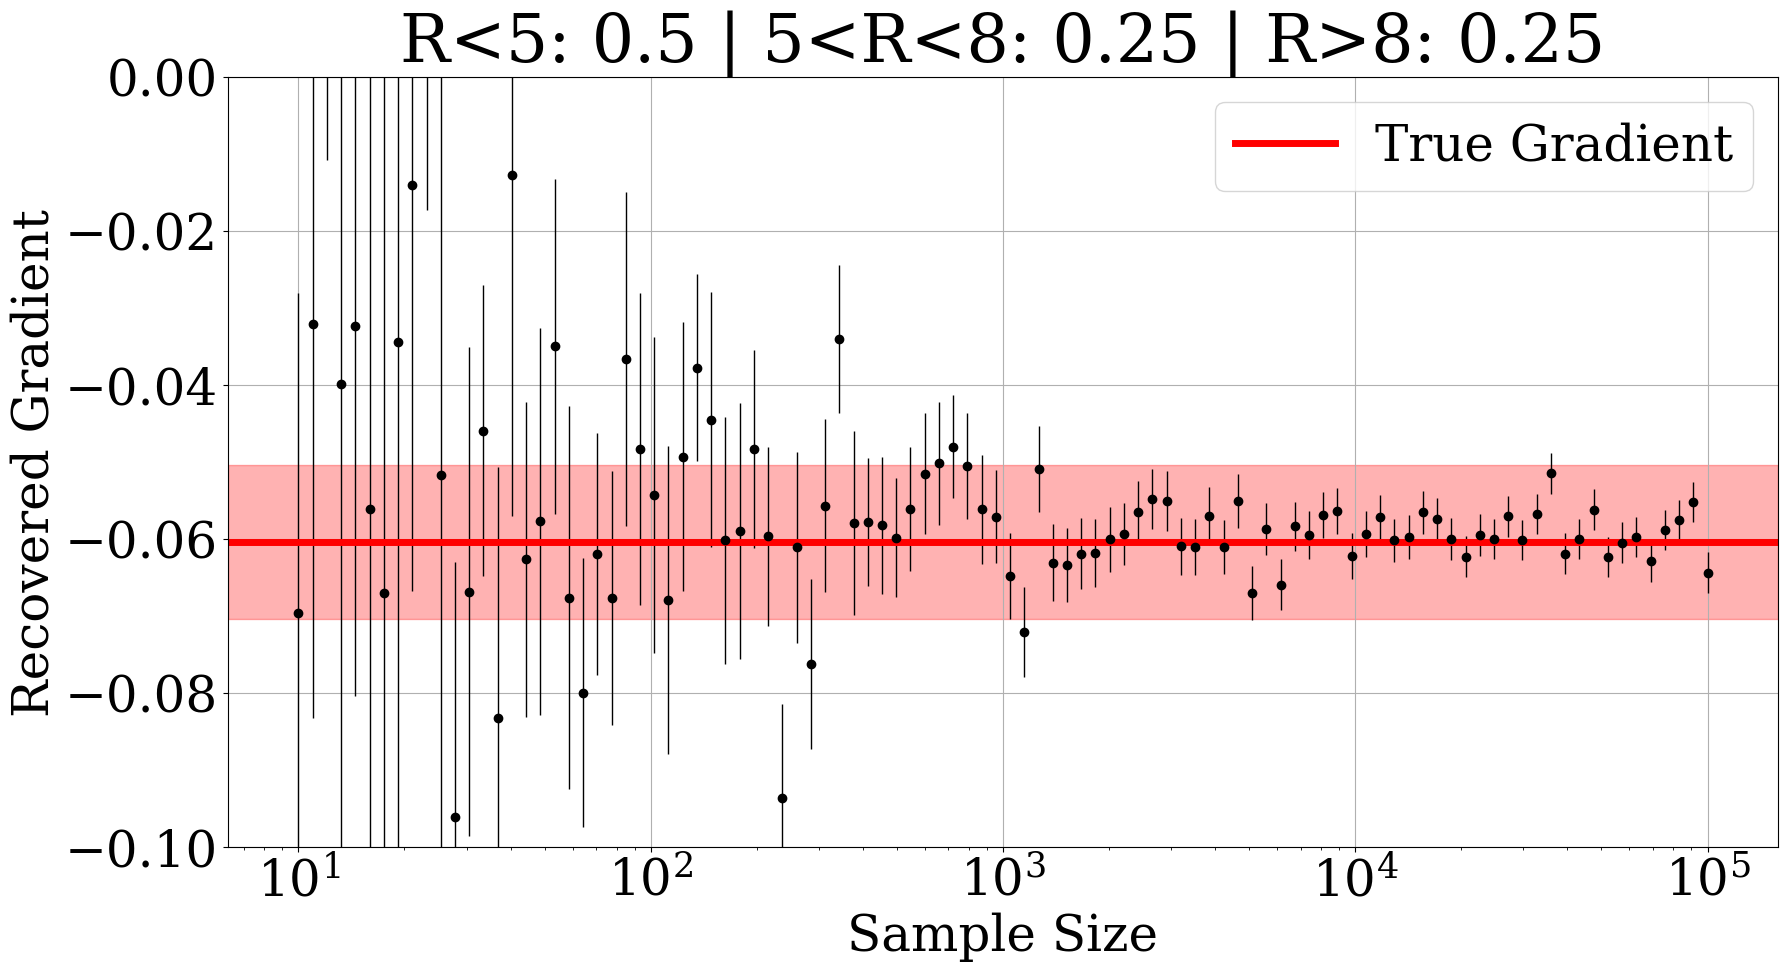

In [97]:
test_samples = np.logspace(1, 5, 100)
test_percents = [0.5, 0.25, 0.25]

slope, slope_err, median_slopes, median_errs = run_gradient_sim(
    test_samples, test_percents
)

plt.figure(figsize=(20, 10))
plt.errorbar(
    test_samples,
    median_slopes,
    yerr=np.array(slope_err) * 2,
    marker="o",
    c="k",
    linestyle="None",
)

plt.axhline(-0.06045024, c="red", lw=5, label="True Gradient")
plt.axhspan(-0.06045024 - 0.01, -0.06045024 + 0.01, color="red", alpha=0.3)

# plt.axhline(-0.05256763, c="red", lw=5, label="True Gradient")

plt.title(
    f"R<5: {test_percents[0]} | 5<R<8: {test_percents[1]} | R>8: {test_percents[2]}",
    fontsize=48,
)
plt.legend()
plt.grid()
plt.ylim(-0.1, 0)
plt.xlabel("Sample Size")
plt.ylabel("Recovered Gradient")
plt.xscale("log")
plt.savefig("slope_skew1.png")
plt.show()

# Skewed Sample 2:

- 50% R < 5 kpc
- 50% 5 < R < 8 kpc
- 0% R > 8 kpc



100%|██████████| 100/100 [01:37<00:00,  1.02it/s]


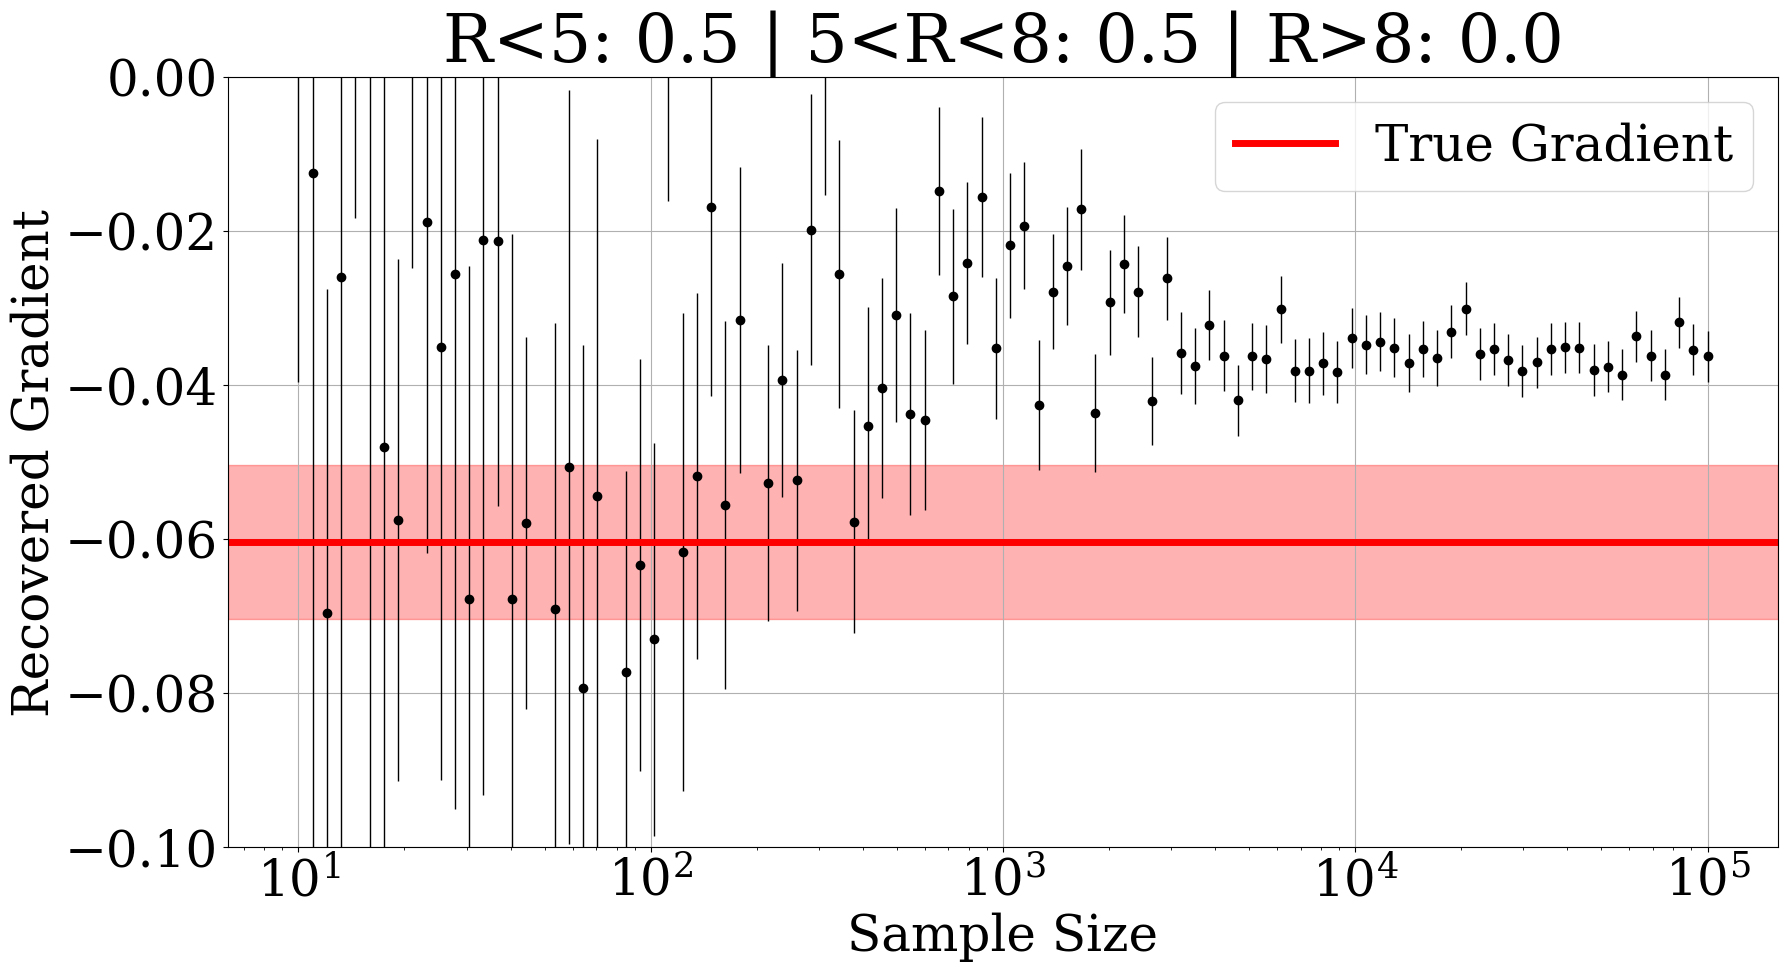

In [98]:
test_samples = np.logspace(1, 5, 100)
test_percents = [0.5, 0.5, 0.0]

slope, slope_err, median_slopes, median_errs = run_gradient_sim(
    test_samples, test_percents
)

plt.figure(figsize=(20, 10))
plt.errorbar(
    test_samples,
    median_slopes,
    yerr=np.array(slope_err) * 2,
    marker="o",
    c="k",
    linestyle="None",
)

plt.axhline(-0.06045024, c="red", lw=5, label="True Gradient")
plt.axhspan(-0.06045024 - 0.01, -0.06045024 + 0.01, color="red", alpha=0.3)

# plt.axhline(-0.05256763, c="red", lw=5, label="True Gradient")

plt.title(
    f"R<5: {test_percents[0]} | 5<R<8: {test_percents[1]} | R>8: {test_percents[2]}",
    fontsize=48,
)
plt.legend()
plt.grid()
plt.ylim(-0.1, 0)
plt.xlabel("Sample Size")
plt.ylabel("Recovered Gradient")
plt.xscale("log")
plt.savefig("slope_skew2.png")
plt.show()

# Skewed Sample 3:
- 0% R < 5 kpc
- 50% 5 < R < 8 kpc
- 50% R > 8 kpc

100%|██████████| 100/100 [01:37<00:00,  1.03it/s]


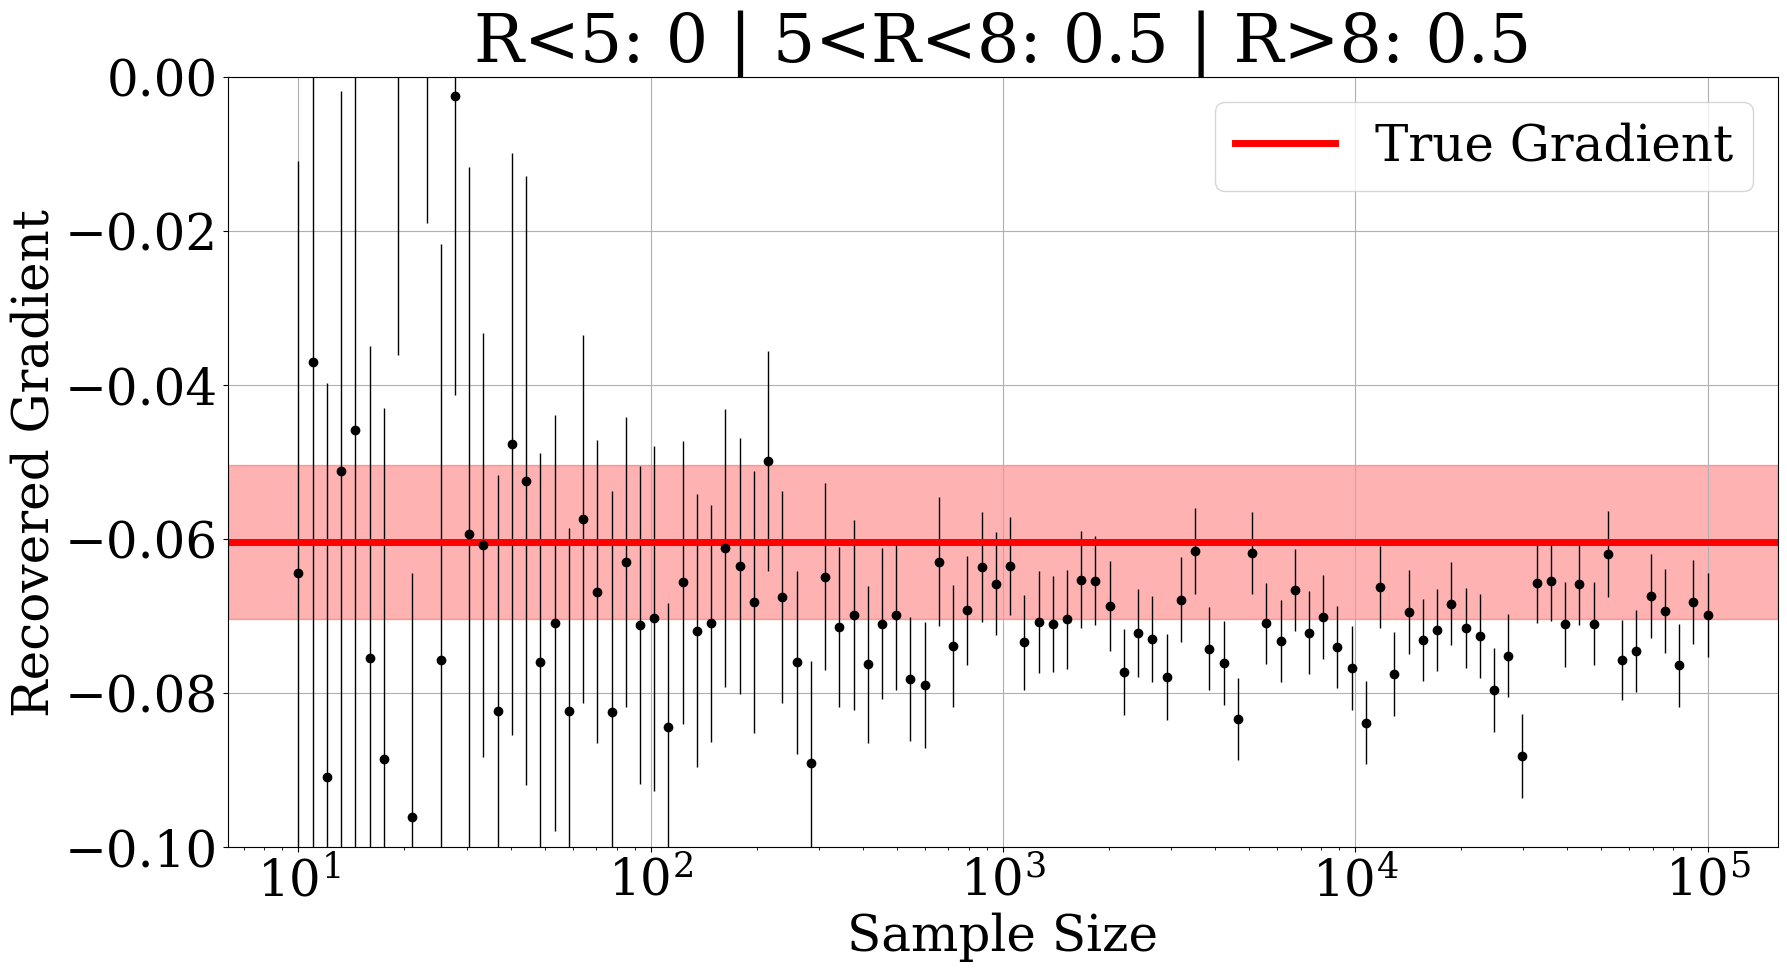

In [100]:
test_samples = np.logspace(1, 5, 100)
test_percents = [0, 0.5, 0.5]

slope, slope_err, median_slopes, median_errs = run_gradient_sim(
    test_samples, test_percents
)

plt.figure(figsize=(20, 10))
plt.errorbar(
    test_samples,
    median_slopes,
    yerr=np.array(slope_err) * 2,
    marker="o",
    c="k",
    linestyle="None",
)

plt.axhline(-0.06045024, c="red", lw=5, label="True Gradient")
plt.axhspan(-0.06045024 - 0.01, -0.06045024 + 0.01, color="red", alpha=0.3)

# plt.axhline(-0.05256763, c="red", lw=5, label="True Gradient")

plt.title(
    f"R<5: {test_percents[0]} | 5<R<8: {test_percents[1]} | R>8: {test_percents[2]}",
    fontsize=48,
)
plt.legend()
plt.grid()
plt.ylim(-0.1, 0)
plt.xlabel("Sample Size")
plt.ylabel("Recovered Gradient")
plt.xscale("log")
plt.savefig("slope_skew3png")
plt.show()

# Skewed Sample 4:
- 5% R < 5 kpc
- 95% 5 < R < 8 kpc
- 5% R > 8 kpc

  0%|          | 0/100 [00:00<?, ?it/s]/Users/jimig/anaconda3/envs/sdss/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/jimig/anaconda3/envs/sdss/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
100%|██████████| 100/100 [01:37<00:00,  1.03it/s]


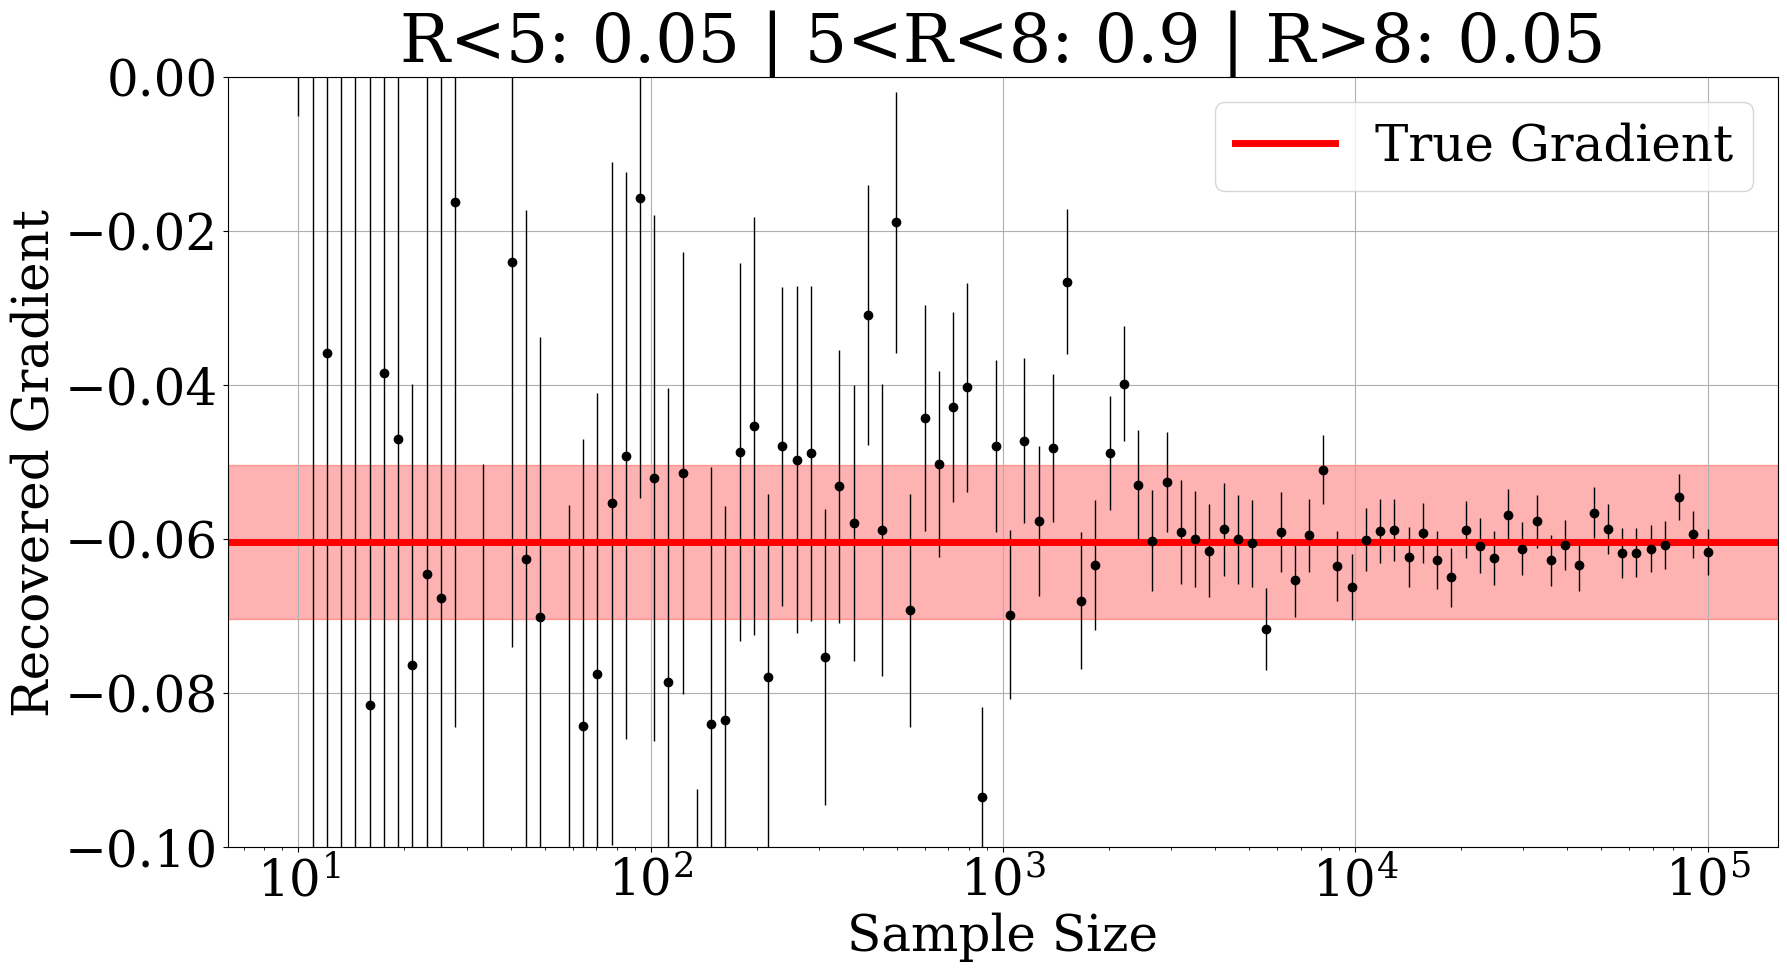

In [101]:
test_samples = np.logspace(1, 5, 100)
test_percents = [0.05, 0.9, 0.05]

slope, slope_err, median_slopes, median_errs = run_gradient_sim(
    test_samples, test_percents
)

plt.figure(figsize=(20, 10))
plt.errorbar(
    test_samples,
    median_slopes,
    yerr=np.array(slope_err) * 2,
    marker="o",
    c="k",
    linestyle="None",
)

plt.axhline(-0.06045024, c="red", lw=5, label="True Gradient")
plt.axhspan(-0.06045024 - 0.01, -0.06045024 + 0.01, color="red", alpha=0.3)

# plt.axhline(-0.05256763, c="red", lw=5, label="True Gradient")

plt.title(
    f"R<5: {test_percents[0]} | 5<R<8: {test_percents[1]} | R>8: {test_percents[2]}",
    fontsize=48,
)
plt.legend()
plt.grid()
plt.ylim(-0.1, 0)
plt.xlabel("Sample Size")
plt.ylabel("Recovered Gradient")
plt.xscale("log")
plt.savefig("slope_skew4png")
plt.show()